# NAÏVE BAYES ON A REVIEW CLASSIFICATION DATASET


## TASK 1: Load & Explore the Dataset

### Load the dataset 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("output.csv")

### Check columns 


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0    Review  1000 non-null   object
 1   Liked    1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


### First 10 rows


In [4]:
df.head(10)

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
5,Now I am getting angry and I want my damn pho.,0
6,Honeslty it didn't taste THAT fresh.),0
7,The potatoes were like rubber and you could te...,0
8,The fries were great too.,1
9,A great touch.,1


### Number of samples per class


In [5]:
# Count number of samples in each class
print(df['Liked'].value_counts())

Liked
1    500
0    500
Name: count, dtype: int64


### Missing values

In [6]:
df.isnull().sum()

 Review    0
Liked      0
dtype: int64

### Review text length distribution

In [7]:
df.columns = df.columns.str.strip()

In [8]:
# Create a new column for review length
df['review_length'] = df['Review'].apply(len)

# Check first few values
print(df[['Review', 'review_length']].head())

                                              Review  review_length
0                           Wow... Loved this place.             24
1                                 Crust is not good.             18
2          Not tasty and the texture was just nasty.             41
3  Stopped by during the late May bank holiday of...             87
4  The selection on the menu was great and so wer...             59


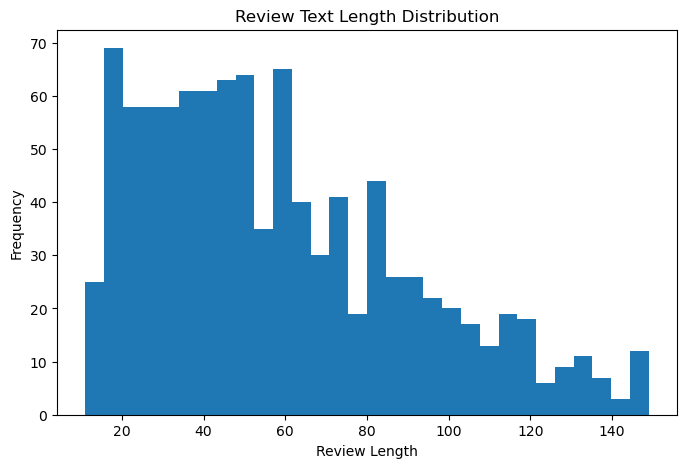

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df['review_length'], bins=30)

plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.title("Review Text Length Distribution")

plt.show()

## TASK 2: Clean & Preprocess the Text


### Convert all text to lowercase


In [10]:
# Convert all reviews to lowercase
df['Review'] = df['Review'].str.lower()

# Check output
print(df['Review'].head())

0                             wow... loved this place.
1                                   crust is not good.
2            not tasty and the texture was just nasty.
3    stopped by during the late may bank holiday of...
4    the selection on the menu was great and so wer...
Name: Review, dtype: object


In [11]:
import re

# Remove punctuation, numbers, and extra spaces
df['Review'] = df['Review'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)   # remove punctuation & numbers
)

df['Review'] = df['Review'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()  # remove extra spaces
)

# Check cleaned reviews
print(df['Review'].head())

0                                 wow loved this place
1                                    crust is not good
2             not tasty and the texture was just nasty
3    stopped by during the late may bank holiday of...
4    the selection on the menu was great and so wer...
Name: Review, dtype: object


### Stopword Removal


In [12]:
# Stopword Removal

from nltk.corpus import stopwords
import nltk

# Store stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords from reviews
df['Review'] = df['Review'].apply(
    lambda x: ' '.join(
        [word for word in x.split() if word not in stop_words]
    )
)

# Check output
print(df['Review'].head())

0                                      wow loved place
1                                           crust good
2                                  tasty texture nasty
3    stopped late may bank holiday rick steve recom...
4                          selection menu great prices
Name: Review, dtype: object


### Lemmatize or stem the words

In [13]:
from nltk.stem import WordNetLemmatizer
import nltk


# Create lemmatizer object
lemmatizer = WordNetLemmatizer()

# Apply lemmatization
df['Review'] = df['Review'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

# Check output
print(df['Review'].head())

0                                      wow loved place
1                                           crust good
2                                  tasty texture nasty
3    stopped late may bank holiday rick steve recom...
4                           selection menu great price
Name: Review, dtype: object


In [14]:
import re

# Remove emojis and special characters
df['Review'] = df['Review'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)

# Remove extra spaces again
df['Review'] = df['Review'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)

# Check output
print(df['Review'].head())

0                                      wow loved place
1                                           crust good
2                                  tasty texture nasty
3    stopped late may bank holiday rick steve recom...
4                           selection menu great price
Name: Review, dtype: object


## TASK 3: Convert Text to Numerical Features


### TF-IDF Vectorizer

In [17]:
### from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
# Create TF-IDF object
tfidf = TfidfVectorizer()

# Transform text
X_tfidf = tfidf.fit_transform(df['Review'])

# Convert to array
X_tfidf = X_tfidf.toarray()
 
print(X_tfidf.shape)
print(X_tfidf)

(1000, 1809)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


## TASK 4: Split the Data


In [18]:
from sklearn.model_selection import train_test_split

# Features and target
X = X_tfidf   # or X_bow
y = df['Liked']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## TASK 5: Train Naïve Bayes Models

### BernoulliNB


In [19]:
from sklearn.naive_bayes import BernoulliNB

# Create model
bnb = BernoulliNB()

# Train model
bnb.fit(X_train, y_train)

# Predictions
y_pred = bnb.predict(X_test)

## TASK 6: Evaluate Models


### Accuracy


In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.75


### Precision

In [21]:
from sklearn.metrics import precision_score

# Calculate precision
precision = precision_score(y_test, y_pred)

print("Precision Score:", precision)

Precision Score: 0.75


### Recall

In [22]:
from sklearn.metrics import recall_score

# Calculate recall
recall = recall_score(y_test, y_pred)

print("Recall Score:", recall)

Recall Score: 0.7788461538461539


### F1 Score


In [23]:
from sklearn.metrics import f1_score

# Calculate F1 Score
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.7641509433962265


###  Confusion matrix




In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[69 27]
 [23 81]]


### Classification report


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.74      0.74        96
           1       0.76      0.76      0.76       104

    accuracy                           0.75       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.75      0.75      0.75       200



## TASK 7: Predict Sentiment of New Reviews


In [31]:
import pandas as pd
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# TF-IDF
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    max_features=3000
)

# Features and target
X = tfidf.fit_transform(df['Review'])

y = df['Liked']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model
model = MultinomialNB()

# Train model
model.fit(X_train, y_train)

# Save model
pickle.dump(model, open("model.pkl", "wb"))

# Save TF-IDF vectorizer
pickle.dump(tfidf, open("tfidf.pkl", "wb"))

print("Model and Vectorizer Saved Successfully")

Model and Vectorizer Saved Successfully


In [25]:
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

# TF-IDF
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    max_features=3000
)

# Features and target
X = tfidf.fit_transform(df['Review'])
y = df['Liked']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model
model = MultinomialNB()

# Train
model.fit(X_train, y_train)

# Save fresh files
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("New pickle files created successfully")

New pickle files created successfully
